In [1]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d belalsafy/egyptian-new-currency-2023

Dataset URL: https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023
License(s): unknown
100% 395M/395M [00:04<00:00, 93.1MB/s]



In [2]:
!unzip egyptian-new-currency-2023.zip

Archive:  egyptian-new-currency-2023.zip
  inflating: dataset/test/1/1.100.jpg  
  inflating: dataset/test/1/1.22.jpg  
  inflating: dataset/test/1/1.24.jpg  
  inflating: dataset/test/1/1.26.jpg  
  inflating: dataset/test/1/1.28.jpg  
  inflating: dataset/test/1/1.40.jpg  
  inflating: dataset/test/1/1.41.jpg  
  inflating: dataset/test/1/1.42.jpg  
  inflating: dataset/test/1/1.5.jpg  
  inflating: dataset/test/1/1.56.jpg  
  inflating: dataset/test/1/1.59.jpg  
  inflating: dataset/test/1/1.6.jpg  
  inflating: dataset/test/1/1.65.jpg  
  inflating: dataset/test/1/1.7.jpg  
  inflating: dataset/test/1/1.70.jpg  
  inflating: dataset/test/1/1.74.jpg  
  inflating: dataset/test/1/1.78.jpg  
  inflating: dataset/test/1/1.79.jpg  
  inflating: dataset/test/1/1.84.jpg  
  inflating: dataset/test/1/1.97.jpg  
  inflating: dataset/test/10 (new)/210.jpg  
  inflating: dataset/test/10 (new)/310.jpg  
  inflating: dataset/test/10 (new)/4110.jpg  
  inflating: dataset/test/10 (new)/510.jpg  


صورة دخل
   ↓
Grayscale          (تحويل لرمادي)
   ↓

Gaussian Blur      (إزالة الضوضاء)
   ↓

Threshold          (فصل الورقة عن الخلفية)
   ↓

Edge Detection     (كشف الحواف)
   ↓

Find Contours      (استخراج شكل الورقة)
   ↓

Crop & Align       (قص الورقة وتصحيح الاتجاه)
   ↓

Feature Extraction (استخراج الـ features)
   ↓

Compare/Classify   (مقارنة مع templates)
   ↓
   
النتيجة: نوع الورقة + القيمة

In [3]:
import cv2
import numpy as np
import pickle
from pathlib import Path
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from skimage.feature import local_binary_pattern, hog
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_PATH = '/content/dataset'
IMG_SIZE     = (224, 224)

CLASS_VALUES = {
    "1": 1.0, "5": 5.0, "10": 10.0,
    "10 (new)": 10.0, "20": 20.0, "20 (new)": 20.0,
    "50": 50.0, "100": 100.0, "200": 200.0
}

def preprocess(img):
    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred   = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edges     = cv2.Canny(thresh, 50, 150)
    kernel    = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed    = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest) > (img.shape[0] * img.shape[1] * 0.1):
            x, y, w, h = cv2.boundingRect(largest)
            return cv2.resize(img[y:y+h, x:x+w], IMG_SIZE)
    return cv2.resize(img, IMG_SIZE)

def extract_features(img):
    processed = preprocess(img)
    gray      = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)

    # Color Histogram
    hsv    = cv2.cvtColor(processed, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv],[0],None,[32],[0,180]).flatten()
    s_hist = cv2.calcHist([hsv],[1],None,[32],[0,256]).flatten()
    v_hist = cv2.calcHist([hsv],[2],None,[32],[0,256]).flatten()
    color  = normalize(np.concatenate([h_hist,s_hist,v_hist]).reshape(1,-1))[0]

    # LBP
    lbp      = local_binary_pattern(gray, 24, 3, method='uniform')
    lbp_h, _ = np.histogram(lbp.ravel(), bins=26, range=(0,26), density=True)

    # HOG
    hog_f, _ = hog(gray, orientations=8, pixels_per_cell=(16,16),
                   cells_per_block=(2,2), visualize=True)
    hog_f    = normalize(hog_f.reshape(1,-1))[0]

    # Color Moments
    moments = []
    for ch in range(3):
        channel = hsv[:,:,ch].astype(float)
        mean    = np.mean(channel)
        std     = np.std(channel)
        skew    = np.mean(((channel - mean) / (std + 1e-6)) ** 3)
        moments.extend([mean, std, skew])

    # Gabor
    gabor = []
    for theta in [0, 45, 90, 135]:
        for freq in [0.1, 0.3, 0.5]:
            kernel = cv2.getGaborKernel(
                (21,21), 5, np.radians(theta), 2*np.pi*freq, 0.5, 0)
            filtered = cv2.filter2D(gray, cv2.CV_64F, kernel)
            gabor.extend([filtered.mean(), filtered.std()])

    # Dominant Colors
    pixels  = processed.reshape(-1, 3).astype(np.float32)
    km      = MiniBatchKMeans(n_clusters=5, n_init=3, random_state=42)
    km.fit(pixels)
    dom_col = normalize(km.cluster_centers_.flatten().reshape(1,-1))[0]

    return np.concatenate([color, lbp_h, hog_f,
                           np.array(moments), np.array(gabor), dom_col])

print("✅ Functions ready!")

✅ Functions ready!


In [4]:
from sklearn.decomposition import PCA

X_all, y_all = [], []

for split in ['train', 'valid']:
    for cls_folder in sorted((Path(DATASET_PATH)/split).iterdir()):
        if not cls_folder.is_dir(): continue
        cls_name = cls_folder.name
        ok = 0
        for img_path in cls_folder.glob("*.jpg"):
            img = cv2.imread(str(img_path))
            if img is None: continue
            try:
                X_all.append(extract_features(img))
                y_all.append(cls_name)
                ok += 1
            except: pass
        print(f"  {split}/{cls_name}: {ok} ✅")

X_all = np.array(X_all)
y_all = np.array(y_all)
print(f"\n📊 Total: {len(X_all)} | Features: {X_all.shape[1]}")

# Scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# PCA
pca   = PCA(n_components=300, whiten=True)
X_pca = pca.fit_transform(X_scaled)
print(f"📉 PCA variance: {pca.explained_variance_ratio_.sum():.2%}")

# SVM
print("\n⏳ Training SVM ...")
svm = SVC(kernel='rbf', C=100, gamma='scale',
          probability=True, class_weight='balanced')
svm.fit(X_pca, y_all)
print("✅ SVM trained!")

# حفظ
with open('svm_model.pkl', 'wb') as f:
    pickle.dump({"svm": svm, "scaler": scaler,
                 "pca": pca, "values": CLASS_VALUES}, f)
print("💾 Saved!")

  train/1: 60 ✅
  train/10: 313 ✅
  train/10 (new): 317 ✅
  train/100: 315 ✅
  train/20: 322 ✅
  train/20 (new): 346 ✅
  train/200: 311 ✅
  train/5: 334 ✅
  train/50: 315 ✅
  valid/1: 20 ✅
  valid/10: 79 ✅
  valid/10 (new): 130 ✅
  valid/100: 80 ✅
  valid/20: 80 ✅
  valid/20 (new): 130 ✅
  valid/200: 78 ✅
  valid/5: 80 ✅
  valid/50: 80 ✅

📊 Total: 3390 | Features: 5578
📉 PCA variance: 76.60%

⏳ Training SVM ...
✅ SVM trained!
💾 Saved!


🎯 Test Accuracy: 75.69%

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
          10       0.75      0.64      0.69        33
    10 (new)       0.77      0.67      0.71        30
         100       0.67      0.86      0.75        35
          20       0.71      0.69      0.70        35
    20 (new)       0.73      1.00      0.85        30
         200       0.75      0.60      0.67        35
           5       0.80      0.91      0.85        35
          50       0.77      0.57      0.66        35

    accuracy                           0.76       288
   macro avg       0.77      0.77      0.76       288
weighted avg       0.76      0.76      0.75       288



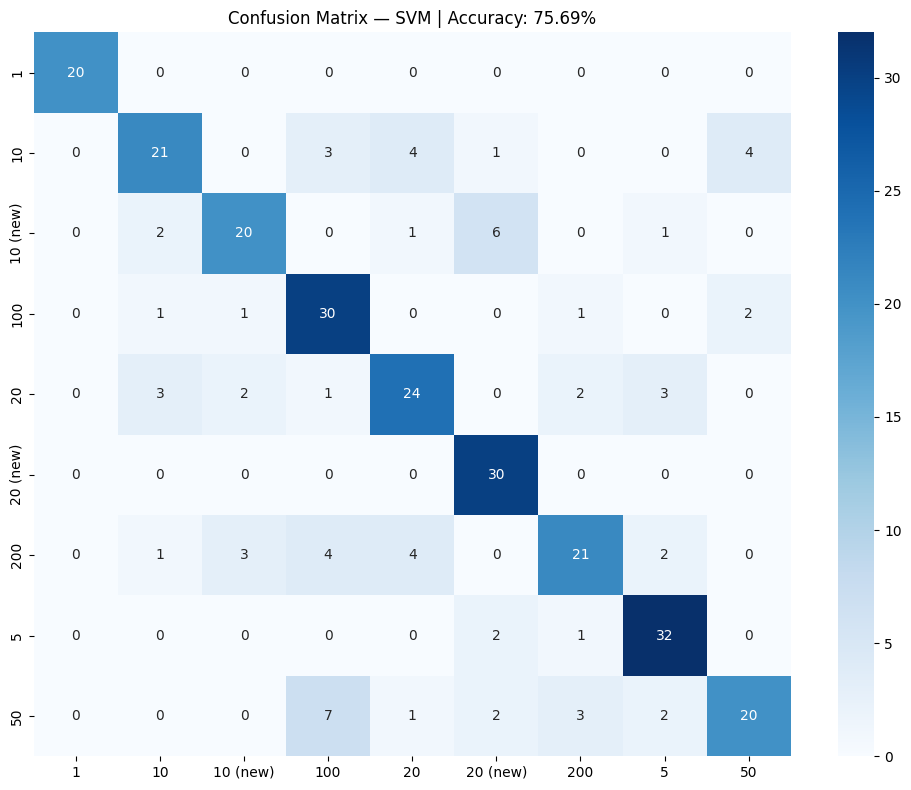

In [5]:
X_test, y_test = [], []
for cls_folder in sorted((Path(DATASET_PATH)/'test').iterdir()):
    if not cls_folder.is_dir(): continue
    for img_path in cls_folder.glob("*.jpg"):
        img = cv2.imread(str(img_path))
        if img is None: continue
        try:
            X_test.append(extract_features(img))
            y_test.append(cls_folder.name)
        except: pass
































X_test_pca = pca.transform(scaler.transform(np.array(X_test)))
y_pred     = svm.predict(X_test_pca)
accuracy   = (y_pred == np.array(y_test)).mean()

print(f"🎯 Test Accuracy: {accuracy:.2%}\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(CLASS_VALUES.keys()))
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=sorted(CLASS_VALUES.keys()),
            yticklabels=sorted(CLASS_VALUES.keys()), cmap='Blues')
plt.title(f'Confusion Matrix — SVM | Accuracy: {accuracy:.2%}')
plt.tight_layout()
plt.show()

In [6]:
import gradio as gr
from PIL import Image

def classify(img_cv2, conf_threshold=0.35):
    feat  = extract_features(img_cv2).reshape(1,-1)
    feat  = pca.transform(scaler.transform(feat))
    pred  = svm.predict(feat)[0]
    proba = svm.predict_proba(feat)[0]
    conf  = proba.max()
    if conf < conf_threshold:
        top2 = proba.argsort()[-2:][::-1]
        if (proba[top2[0]] - proba[top2[1]]) < 0.15:
            return "غير واضح", conf, 0.0
    return pred, conf, CLASS_VALUES.get(pred, 0.0)

def visualize(img, cls_name, conf):
    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(
        cv2.GaussianBlur(gray,(5,5),0), 0, 255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    edges   = cv2.Canny(thresh, 50, 150)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
    closed  = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    contours,_ = cv2.findContours(closed, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    vis = img.copy()
    if contours:
        largest = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest) > img.shape[0]*img.shape[1]*0.05:
            cv2.drawContours(vis,[largest],-1,(0,255,100),3)
            x,y,w,h = cv2.boundingRect(largest)
            cv2.rectangle(vis,(x,y),(x+w,y+h),(0,200,255),2)
    label = f"{cls_name} EGP | {conf:.0%}"
    cv2.rectangle(vis,(10,10),(320,50),(0,0,0),-1)
    cv2.putText(vis,label,(15,38),
                cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,100),2)
    return vis

def process(img1, img2):
    results, total, out_imgs = "", 0.0, []
    for i, pil_img in enumerate([img1, img2], 1):
        if pil_img is None:
            out_imgs.append(None)
            continue
        img_cv2          = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        cls_name, conf, value = classify(img_cv2)
        vis              = visualize(img_cv2, cls_name, conf)
        total           += value
        if cls_name == "غير واضح":
            results += f"🖼️ صورة {i}: ⚠️ مش واضح — جرب صورة أوضح\n"
        else:
            results += f"🖼️ صورة {i}: {cls_name} جنيه | {conf:.1%} | {value} EGP\n"
        out_imgs.append(
            Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)))

    results += f"\n{'='*30}\n💰 الإجمالي: {total} جنيه"
    pad = [None] * (2 - len(out_imgs))
    return (out_imgs+pad)[0], (out_imgs+pad)[1], results

with gr.Blocks(title="Egyptian Banknote Counter") as demo:
    gr.Markdown("""
    # 🏦 Egyptian Banknote Counter
    **Traditional CV:** Grayscale → Threshold → Edge → Contour → SVM
    """)
    with gr.Row():
        img1 = gr.Image(label="الصورة الأولى",  type="pil")
        img2 = gr.Image(label="الصورة التانية (اختياري)", type="pil")
    btn = gr.Button("🔍 احسب", variant="primary")
    with gr.Row():
        out1 = gr.Image(label="نتيجة الصورة الأولى")
        out2 = gr.Image(label="نتيجة الصورة التانية")
    text = gr.Textbox(label="📊 النتيجة", lines=6)
    btn.click(fn=process, inputs=[img1,img2], outputs=[out1,out2,text])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://07fa4ff3e9507a6ede.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
